# XAI-FUNGI

**Cel:** Niezależne (nienadzorowane) zbadanie, jak naturalnie grupują się uczestnicy na podstawie samego języka i zachowań w wywiadach; sprawdzenie, czy wyłaniają się profile odpowiadające DE/IT/SSH lub innym cechom znanym z ankiet (bez użycia SURVEY w modelowaniu).

- **DE** - eksperci dziedzinowi (mykolodzy),
- **IT** - studenci informatyki,
- **SSH** - studenci kierunków społeczno-humanistycznych.

Etykiety DE/IT/SSH nigdy nie znajdują się w cechach - służą wyłącznie do walidacji klastrów po fakcie. Modelowanie jest w pełni nienadzorowane. Próba liczy **N = 38** uczestników.

[XAI-FUNGI](https://zenodo.org/records/15222484)


In [1]:
# %pip install -q pandas numpy matplotlib scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

from src.dataset import download_dataset
from src.transcripts import (
    load_all_transcripts,
    filter_only_participants,
    concat_text_per_participant,
)
from src.features import (
    get_stopwords,
    simple_features,
    tfidf_svd_features,
    top_terms_per_cluster,
    slide_topic_features,
    topic_none_share,
)
from src.responses import load_problems_responses, load_problems, response_features
from src.maxqda import load_maxqda_summary, code_count_features, top_codes_per_group

## 1. Setup

Funkcja `download_dataset` pobiera rekord z Zenodo przez ich publiczne API, zapisuje pliki i rozpakowuje archiwa - pliki już obecne są pomijane.


In [3]:
download_dataset(data_dir="data")

save	CODEBOOK.csv
save	MAXQDA_SUMMARY.csv
save	ORIGINAL_VISUALIZATIONS.pdf
save	ORIGINAL_VISUALIZATIONS_EN.pdf
save	PROBLEMS.csv
save	PROBLEMS_RESPONSES.csv
save	PROBLEMS_en.csv
save	QUESTIONS.csv
save	SLIDES.csv
save	SURVEY.csv
save	SURVEY_en.csv
unzip	TRANSCRIPTS.zip -> TRANSCRIPTS/
save	VISUALIZATION_MODIFICATIONS.csv
unzip	VISUALIZATION_MODIFICATIONS.zip -> VISUALIZATION_MODIFICATIONS/


Lista polskich _stopwords_ jest pobierana z zewnętrznego źródła [stopwords-iso](https://github.com/stopwords-iso/stopwords-pl).


In [4]:
stopwords = get_stopwords()
print("Number of stopwords:", len(stopwords))
print("Sample:", stopwords[:15])

Number of stopwords: 331
Sample: ['a', 'aby', 'ach', 'acz', 'aczkolwiek', 'aj', 'albo', 'ale', 'ależ', 'ani', 'anonimizacja', 'aż', 'bardziej', 'bardzo', 'bez']


## 2. Transkrypcje

Każdy plik CSV w `data/TRANSCRIPTS/` to jeden wywiad - struktura: wiersz na wypowiedź.


In [5]:
df = load_all_transcripts()
print("Total rows (utterances):", len(df))
print("Participants:", df["participant_id"].nunique())
df.head()

Total rows (utterances): 14835
Participants: 38


,speaker_id,slide_id,question_id,problem_id,text,participant_id,group
0,DR,NaN,NaN,NaN,Transkrypcja została włączona i ona sobie tut...,DR_IT_05,IT
1,DR,NaN,NaN,NaN,Tak mamy.,DR_IT_05,IT
2,DR,NaN,NaN,NaN,"I zrobimy może w ten sposób, że ja panią zap...",DR_IT_05,IT
3,DR,NaN,NaN,NaN,Około pani.,DR_IT_05,IT
4,DR,NaN,NaN,NaN,Wszystko jest w porządku.,DR_IT_05,IT


In [6]:
df.drop_duplicates("participant_id")["group"].value_counts()

group
SSH    18
DE     12
IT      8
Name: count, dtype: int64

W transkrypcie przeplatają się wypowiedzi badacza i uczestnika. Pytania badacza mogłyby maskować realne różnice - `filter_only_participants` odrzuca wypowiedzi badacza.


In [7]:
print("Before filtering:", len(df))
df_part = filter_only_participants(df)
print("After filtering (participants only):", len(df_part))

Before filtering: 14835
After filtering (participants only): 11434


In [8]:
text_df = concat_text_per_participant(df_part)
print("One row per participant:", text_df.shape)
text_df.head()

One row per participant: (38, 3)


,participant_id,group,text
0,DR_IT_05,IT,", czyli wzięły nam zostanie z niego. Że jest z..."
1,DR_SSH_01,SSH,"Tak, jestem gotowa Czyli odpowiedzieć mam na p..."
2,DR_SSH_02,SSH,W porządku zatem można tam póki co czytam pier...
3,DR_SSH_03,SSH,W takim razie czytam prezentację. Tam zapewn...
4,DR_SSH_04,SSH,"Czyli będę musiał wysyłać wszystko, co robię ..."


Średnia długość wypowiedzi (znaki) per grupa.


In [9]:
text_df["text_len"] = text_df["text"].str.len()
text_df.groupby("group")["text_len"].agg(["mean", "min", "max"]).round(0)

,mean,min,max
group,,,
DE,24467.0,8937,46040
IT,38115.0,12053,89637
SSH,33791.0,18763,67506


Eksperci (DE) mówią krócej niż studenci - pierwszy sygnał, że grupy faktycznie mogą różnić się stylem wypowiedzi.


## 3. Cechy lingwistyczne

Sześć interpretowalnych statystyk opisujących _w jaki sposób_ ktoś mówi:

- długość wypowiedzi,
- różnorodność leksykalna,
- średnia długość słowa,
- liczba pytań,
- liczba wzmianek o niepewności ("chyba", "może", "przypuszczam"),
- liczba wzmianek o niewiedzy ("nie rozumiem", "nie potrafię").

Wskaźniki są normalizowane na 1000 słów.


In [10]:
feats = simple_features(text_df)
feats.head(10)

,n_words,ttr,avg_word_len,questions_per_1k,uncertainty_per_1k,ignorance_per_1k
participant_id,,,,,,
DR_IT_05,5394,0.281795,5.106971,10.938079,17.241379,3.151650
DR_SSH_01,2873,0.322659,5.351549,6.961364,15.315002,2.436478
DR_SSH_02,6406,0.243834,5.082111,4.527006,19.669060,3.434280
DR_SSH_03,4157,0.230936,5.324753,2.165023,24.777484,1.443349
DR_SSH_04,3388,0.270956,4.858619,10.035419,14.462810,6.788666
DR_SSH_06,5905,0.271804,4.940728,13.717189,16.088061,5.080440
DR_SSH_07,5053,0.205225,4.869187,7.124481,17.811201,10.093014
MK_IT_03,7458,0.192947,5.022526,6.972379,23.732904,4.022526
MK_IT_06,5156,0.220132,4.821373,5.818464,27.734678,4.460822


In [11]:
feats_with_group = feats.join(text_df.set_index("participant_id")["group"])
feats_with_group.groupby("group").mean().round(2)

,n_words,ttr,avg_word_len,questions_per_1k,uncertainty_per_1k,ignorance_per_1k
group,,,,,,
DE,3898.50,0.28,4.97,7.39,14.81,3.80
IT,6201.12,0.23,4.92,7.93,21.11,4.86
SSH,5488.78,0.23,4.94,8.51,21.29,5.33


Cechy standaryzowane (`StandardScaler`), ponieważ występują w różnych skalach.


In [12]:
ids = feats.index.tolist()
X_scaled = StandardScaler().fit_transform(feats.values)

In [13]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)

results = pd.DataFrame({"participant_id": ids, "cluster": clusters})
results = results.merge(text_df[["participant_id", "group"]], on="participant_id")
print(results["cluster"].value_counts().sort_index())

cluster
0    16
1    13
2     9
Name: count, dtype: int64


In [14]:
pd.crosstab(results["cluster"], results["group"], margins=True, margins_name="Sum")

group,DE,IT,SSH,Sum
cluster,,,,
0,10,3,3,16
1,2,3,8,13
2,0,2,7,9
Sum,12,8,18,38


Opierając się wyłącznie na cechach lingwistycznych, można jedynie w niewielkim stopniu wydzielić klaster DE (zdominowany przez ekspertów). Profile studentów IT oraz SSH silnie się na siebie nakładają, a brak wyraźnych granic między tymi grupami znajduje potwierdzenie w dwuwymiarowej wizualizacji `PCA`.


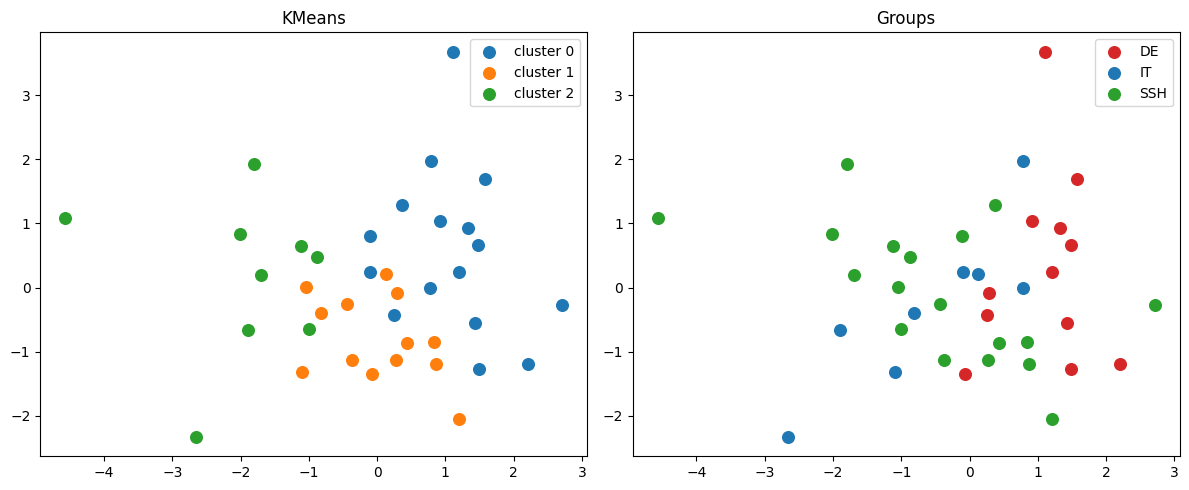

In [15]:
Path("img").mkdir(exist_ok=True)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for c in sorted(results["cluster"].unique()):
    mask = results["cluster"] == c
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], label=f"cluster {c}", s=70)
axes[0].set_title("KMeans")
axes[0].legend()

colors = {"DE": "tab:red", "IT": "tab:blue", "SSH": "tab:green"}
for g, col in colors.items():
    mask = results["group"] == g
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], label=g, s=70, c=col)
axes[1].set_title("Groups")
axes[1].legend()

plt.tight_layout()
plt.savefig("img/kmeans.png", dpi=110, bbox_inches="tight")
plt.show()

## 4. TF-IDF + LSA

TF-IDF wektoryzuje słownictwo każdego uczestnika, ponieważ klastrowanie może wychwycić różnice treści (np. terminologia ekspercka vs. język opisowy studentów). Surowa macierz TF-IDF jest zbyt rzadka dla 38 osób, redukowana jest więc do 15 wymiarów metodą `TruncatedSVD` (LSA).


In [16]:
tfidf_feats = tfidf_svd_features(text_df, n_components=15)
print("TF-IDF SVD frame:", tfidf_feats.shape)
tfidf_feats.head()

TF-IDF SVD frame: (38, 15)


,tfidf_svd_1,tfidf_svd_2,tfidf_svd_3,tfidf_svd_4,tfidf_svd_5,tfidf_svd_6,tfidf_svd_7,tfidf_svd_8,tfidf_svd_9,tfidf_svd_10,tfidf_svd_11,tfidf_svd_12,tfidf_svd_13,tfidf_svd_14,tfidf_svd_15
participant_id,,,,,,,,,,,,,,,
DR_IT_05,0.401188,-0.062662,0.000797,0.141671,-0.187077,0.047499,0.038423,0.229655,0.533235,0.334711,0.365886,0.228919,0.114230,-0.176664,0.252094
DR_SSH_01,0.518549,-0.221667,-0.160153,-0.226320,0.009679,-0.006985,-0.359645,-0.149417,0.158475,0.020369,-0.011053,-0.161135,-0.185058,-0.074079,0.051013
DR_SSH_02,0.655268,-0.234426,0.057717,-0.052759,-0.215774,0.156169,-0.123689,-0.047661,0.063210,-0.100332,-0.047623,-0.103308,0.064462,-0.047155,0.060397
DR_SSH_03,0.496278,-0.177339,-0.014926,-0.324127,-0.040186,0.026903,-0.217503,-0.172685,0.194744,-0.112754,0.077800,0.033021,-0.156673,0.392993,0.190197
DR_SSH_04,0.531457,-0.141931,-0.178489,-0.158073,0.188097,-0.196706,-0.234111,-0.003713,-0.060791,0.190230,0.122823,0.046934,-0.122617,0.073945,0.023475


In [17]:
X_tfidf = tfidf_feats.values
kmeans_tfidf = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters_tfidf = kmeans_tfidf.fit_predict(X_tfidf)

results_tfidf = pd.DataFrame(
    {"participant_id": tfidf_feats.index.tolist(), "cluster": clusters_tfidf}
).merge(text_df[["participant_id", "group"]], on="participant_id")

pd.crosstab(
    results_tfidf["cluster"], results_tfidf["group"], margins=True, margins_name="Sum"
)

group,DE,IT,SSH,Sum
cluster,,,,
0,2,7,18,27
1,10,0,0,10
2,0,1,0,1
Sum,12,8,18,38


TF-IDF radzi sobie wyraźnie lepiej niż sześć cech prostych - jeden klaster zbiera niemal wszystkich ekspertów DE.


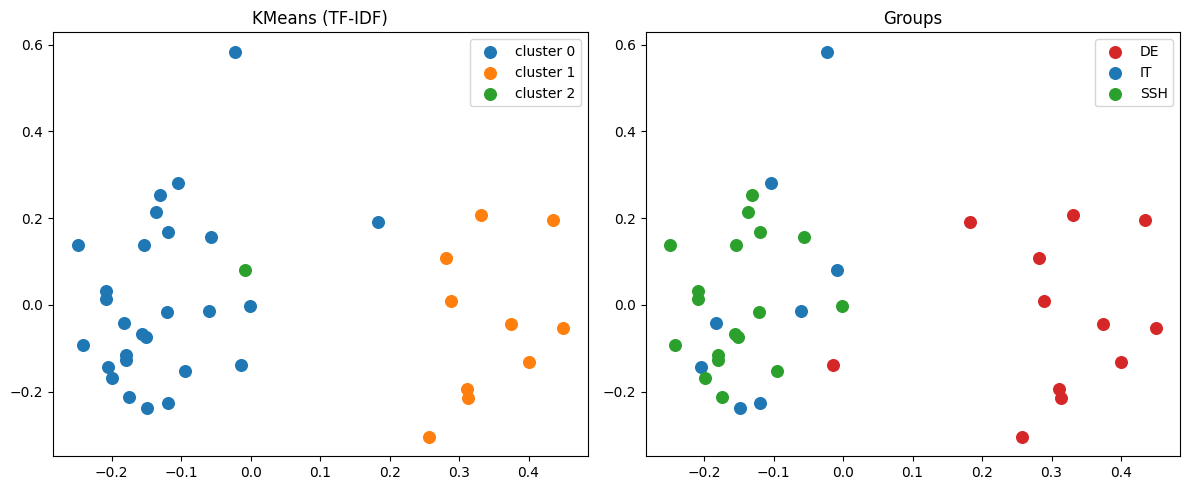

In [18]:
X_tfidf_2d = PCA(n_components=2, random_state=42).fit_transform(X_tfidf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for c in sorted(results_tfidf["cluster"].unique()):
    mask = results_tfidf["cluster"] == c
    axes[0].scatter(
        X_tfidf_2d[mask, 0], X_tfidf_2d[mask, 1], label=f"cluster {c}", s=70
    )
axes[0].set_title("KMeans (TF-IDF)")
axes[0].legend()

for g, col in colors.items():
    mask = results_tfidf["group"] == g
    axes[1].scatter(X_tfidf_2d[mask, 0], X_tfidf_2d[mask, 1], label=g, s=70, c=col)
axes[1].set_title("Groups")
axes[1].legend()

plt.tight_layout()
plt.savefig("img/kmeans_tfidf.png", dpi=110, bbox_inches="tight")
plt.show()

Najbardziej charakterystyczne terminy per klaster - pomoc w interpretacji.


In [19]:
top_terms = top_terms_per_cluster(text_df, clusters_tfidf, top_k=15)
for cluster_id, terms in top_terms.items():
    print(f"cluster {cluster_id}:", ", ".join(t for t, _ in terms))

cluster 0: myślę, wydaje, wartość, trochę, raczej, brak, wpływ, stanie, sumie, wykresu, zmienia, znaczy, wartości, slajd, faktycznie
cluster 1: mhm, znaczy, yy, gatunków, gatunki, brak, gatunek, powiem, oczywiście, śmiech, powiedzmy, stanie, dokładnie, myślę, cecha
cluster 2: niewyraźne, faktycznie, powiedzmy, stanie, większość, powiedziałabym, wartość, wartości, odczytać, napisane, centymetrach, naprawdę, pewna, pytanie, troszkę


### 4.1. TF-IDF + cechy lingwistyczne

Połączenie obu podejść. Każdy blok standaryzowany osobno, żeby skala nie faworyzowała żadnego z nich.


In [20]:
X_combined = np.hstack(
    [
        StandardScaler().fit_transform(feats.loc[tfidf_feats.index].values),
        StandardScaler().fit_transform(tfidf_feats.values),
    ]
)
kmeans_combined = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters_combined = kmeans_combined.fit_predict(X_combined)

results_combined = pd.DataFrame(
    {"participant_id": tfidf_feats.index.tolist(), "cluster": clusters_combined}
).merge(text_df[["participant_id", "group"]], on="participant_id")

pd.crosstab(
    results_combined["cluster"],
    results_combined["group"],
    margins=True,
    margins_name="Sum",
)

group,DE,IT,SSH,Sum
cluster,,,,
0,11,2,6,19
1,1,1,2,4
2,0,5,10,15
Sum,12,8,18,38


Miarą jakości klastrów są wskaźniki **ARI** i **NMI** - im wyższe, tym lepiej klaster odpowiada prawdziwym grupom DE/IT/SSH.

- **ARI** (Adjusted Rand Index) patrzy na pary uczestników: czy dwie osoby, które wylądowały razem w jednym klastrze, są też razem w tej samej prawdziwej grupie (i odwrotnie: czy osoby przypisane do różnych klastrów są w różnych grupach). ARI ~ 0 to przypisanie losowe, ARI = 1 - idealna zgodność (przy bardzo złym podziale może przyjąć wartość poniżej zera).
- **NMI** (Normalized Mutual Information) podchodzi do tematu od strony teorii informacji: pyta, o ile zmniejsza się niepewność co do prawdziwej grupy uczestnika, gdy poznamy numer jego klastra. Znormalizowane do [0, 1]: 0 - numer klastra nie zdradza nic o grupie (rozkłady niezależne), NMI = 1 - klaster jednoznacznie wyznacza grupę.


In [21]:
ordered_ids = tfidf_feats.index
groups_true = text_df.set_index("participant_id").loc[ordered_ids, "group"].values


def score(predicted):
    return {
        "ARI": adjusted_rand_score(groups_true, predicted),
        "NMI": normalized_mutual_info_score(groups_true, predicted),
    }


pd.DataFrame(
    {
        "simple_features": score(clusters),
        "tfidf_svd": score(clusters_tfidf),
        "simple + tfidf": score(clusters_combined),
    }
).T.round(3)

,ARI,NMI
simple_features,0.144,0.204
tfidf_svd,0.443,0.540
simple + tfidf,0.169,0.227


Dodanie cech prostych do TF-IDF pogarsza wynik - sześć zgrubnych statystyk wprowadza szum do dobrze działającego sygnału słownikowego.


## 5. Cechy behawioralne

Po obejrzeniu wyjaśnień każdy uczestnik oceniał trzy grzyby jako jadalne/trujące oraz deklarował własną pewność w 5-stopniowej skali. Cechy te opisują co uczestnicy zrobili - ich decyzje i samooceny pewności (cechy behawioralne). Uwzględnione cechy:

- `accuracy` - odsetek decyzji zgodnych,
- `mean_certainty` - średnia pewność (skala od -2 do +2),
- `frac_cant_assess` - odsetek odpowiedzi "nie umiem ocenić",
- `overconfidence` - liczba decyzji błędnych mimo zadeklarowanej pewności.

**Ograniczenie**  
Eksperci (DE) nie wykonywali tego zadania, więc cechy pokrywają tylko studentów (IT + SSH). Użycie ich na całej próbie trywialnie oddzieliłoby DE (same braki) od studentów - byłby to artefakt protokołu, a nie realna różnica poznawcza. Dlatego ograniczono się tu do podzbioru studentów (**N = 26**).


In [22]:
responses = load_problems_responses()
problems = load_problems()
resp_feats = response_features(responses, problems)

print(
    "Coverage:",
    len(resp_feats),
    "/",
    text_df["participant_id"].nunique(),
    "participants",
)
resp_feats.head(10).round(2)

Coverage: 26 / 38 participants


,accuracy,mean_certainty,frac_cant_assess,overconfidence
participant_id,,,,
DR_IT_05,0.67,-1.33,0.00,0
DR_SSH_01,0.0,1.33,0.00,3
DR_SSH_02,0.33,0.00,0.33,1
DR_SSH_03,0.0,0.67,0.33,2
DR_SSH_04,0.33,-1.00,0.00,1
DR_SSH_06,0.0,-1.00,0.00,0
DR_SSH_07,0.67,1.00,0.00,1
MK_IT_03,0.33,1.00,0.00,2
MK_IT_06,0.33,2.00,0.00,2


In [23]:
resp_feats.join(text_df.set_index("participant_id")["group"]).groupby("group").mean(
    numeric_only=True
).round(2)

,accuracy,mean_certainty,frac_cant_assess,overconfidence
group,,,,
IT,0.42,0.71,0.12,1.25
SSH,0.33,0.13,0.13,1.06


### 5.1. Czy da się odróżnić IT od SSH?

TF-IDF dość dobrze wyodrębnia klaster ekspertów, ale otwarte pozostaje pytanie: czy wśród studentów widać granicę IT - SSH? Sprawdzenie trzech wariantów cech, każdy z KMeans dla `k = 2`:

- **`tfidf_sub`** - tylko TF-IDF, policzone od nowa tylko na podzbiorze studentów,
- **`behavioral_sub`** - tylko cechy behawioralne (decyzje + pewność),
- **`tfidf + beh_sub`** - konkatenacja obu bloków - każdy standaryzowany osobno.


In [24]:
subset_ids = resp_feats.index.tolist()
text_sub = text_df[text_df["participant_id"].isin(subset_ids)].reset_index(drop=True)

tfidf_sub = tfidf_svd_features(text_sub, n_components=10)
beh_sub = resp_feats.loc[tfidf_sub.index]

X_tfidf_sub = StandardScaler().fit_transform(tfidf_sub.values)
X_beh_sub = StandardScaler().fit_transform(beh_sub.values)
X_comb_sub = np.hstack([X_tfidf_sub, X_beh_sub])

clusters_tfidf_sub = KMeans(n_clusters=2, random_state=42, n_init=20).fit_predict(
    X_tfidf_sub
)
clusters_beh_sub = KMeans(n_clusters=2, random_state=42, n_init=20).fit_predict(
    X_beh_sub
)
clusters_comb_sub = KMeans(n_clusters=2, random_state=42, n_init=20).fit_predict(
    X_comb_sub
)

groups_sub = text_sub.set_index("participant_id").loc[tfidf_sub.index, "group"].values


def score_sub(c):
    return {
        "ARI": adjusted_rand_score(groups_sub, c),
        "NMI": normalized_mutual_info_score(groups_sub, c),
    }


pd.DataFrame(
    {
        "tfidf_sub": score_sub(clusters_tfidf_sub),
        "behavioral_sub": score_sub(clusters_beh_sub),
        "tfidf + beh_sub": score_sub(clusters_comb_sub),
    }
).T.round(3)

,ARI,NMI
tfidf_sub,-0.014,0.008
behavioral_sub,0.063,0.088
tfidf + beh_sub,-0.030,0.010


In [25]:
pd.crosstab(
    pd.Series(clusters_comb_sub, name="cluster"),
    pd.Series(groups_sub, name="group"),
    margins=True,
    margins_name="Sum",
)

group,IT,SSH,Sum
cluster,,,
0,3,9,12
1,5,9,14
Sum,8,18,26


**ARI** bliskie zera (nawet ujemne), żaden z trzech wariantów nie jest w stanie rozdzielić IT od SSH. Klastry mieszają obie grupy mniej więcej proporcjonalnie. Granica IT - SSH jest realnie bardzo słaba.


## 6. Kody tematyczne jako cechy

`MAXQDA_SUMMARY.csv` zawiera, per uczestnik, ile razy każdy kod jakościowy został przypisany do jego wywiadu. To interpretacje badaczy, więc najbogatszy, ale i najmniej surowy sygnał.


In [26]:
maxqda = load_maxqda_summary()
maxqda_feats = code_count_features(maxqda, normalize=True)
print("Frame:", maxqda_feats.shape)
print(
    "Coverage:",
    maxqda_feats.index.isin(text_df["participant_id"]).sum(),
    "/",
    len(text_df),
)
maxqda_feats.iloc[:5, :6].round(3)

Frame: (38, 82)
Coverage: 38 / 38


,aesthetics,aesthetics > colour scheme,aesthetics > font size,aesthetics > layout,affects,affects > interest
participant_id,,,,,,
DR_IT_05,0.000,0.000,0.000,0.000,0.0,0.00
DR_SSH_01,0.016,0.031,0.008,0.008,0.0,0.00
DR_SSH_02,0.008,0.029,0.005,0.013,0.0,0.00
DR_SSH_03,0.000,0.010,0.000,0.000,0.0,0.01
DR_SSH_04,0.000,0.000,0.000,0.000,0.0,0.00


In [27]:
groups_map = text_df.set_index("participant_id")["group"]
top_codes = top_codes_per_group(maxqda, groups_map, top_k=5)

for grp in ["DE", "IT", "SSH"]:
    print(f"Top 5 codes for {grp}:")
    for code_name, val in top_codes[grp].items():
        print(f"\t{val:.3f}  {code_name}")
    print()

Top 5 codes for DE:
	0.097  knowledge and experience > knowledge and experience in fungi
	0.067  evaluation criteria > importance
	0.058  evaluation criteria > unreadability
	0.057  methods of analysis > taxons
	0.051  methods of analysis > omission

Top 5 codes for IT:
	0.099  evaluation criteria > comprehensibility
	0.076  data and features > understanding of annotations
	0.063  data and features > feature significance
	0.060  evaluation criteria > unreadability
	0.045  evaluation criteria > appropriateness

Top 5 codes for SSH:
	0.094  evaluation criteria > comprehensibility
	0.076  data and features > feature significance
	0.069  data and features > understanding of annotations
	0.050  evaluation criteria > unreadability
	0.042  methods of analysis > example analysis



In [28]:
X_maxqda = StandardScaler().fit_transform(maxqda_feats.loc[ordered_ids].values)

clusters_maxqda = KMeans(n_clusters=3, random_state=42, n_init=20).fit_predict(X_maxqda)

results_maxqda = pd.DataFrame(
    {"participant_id": ordered_ids.tolist(), "cluster": clusters_maxqda}
).merge(text_df[["participant_id", "group"]], on="participant_id")

pd.crosstab(
    results_maxqda["cluster"], results_maxqda["group"], margins=True, margins_name="Sum"
)

group,DE,IT,SSH,Sum
cluster,,,,
0,12,0,0,12
1,0,6,10,16
2,0,2,8,10
Sum,12,8,18,38


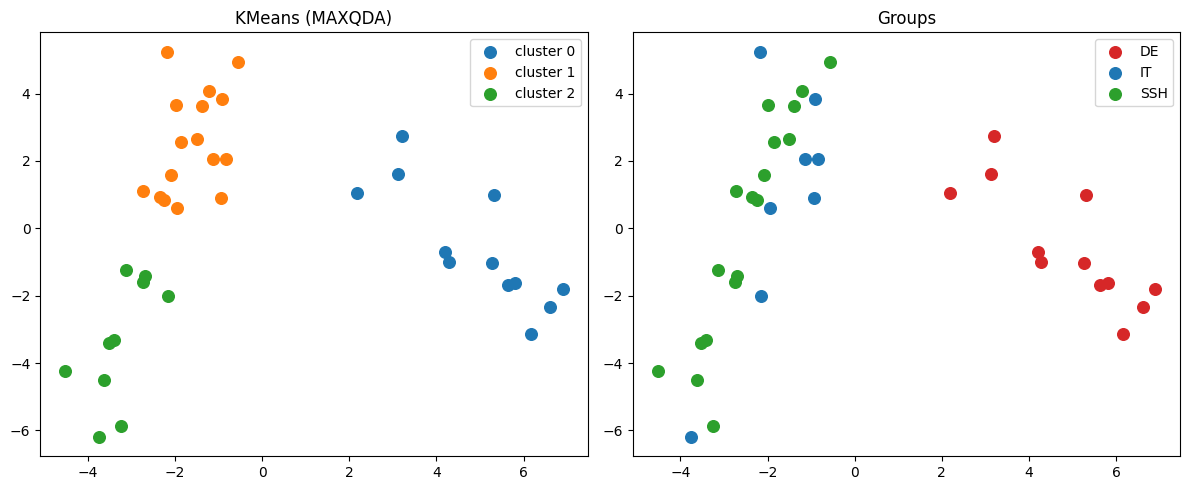

In [29]:
X_maxqda_2d = PCA(n_components=2, random_state=42).fit_transform(X_maxqda)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for c in sorted(results_maxqda["cluster"].unique()):
    mask = results_maxqda["cluster"] == c
    axes[0].scatter(
        X_maxqda_2d[mask, 0], X_maxqda_2d[mask, 1], label=f"cluster {c}", s=70
    )
axes[0].set_title("KMeans (MAXQDA)")
axes[0].legend()

for g, col in colors.items():
    mask = results_maxqda["group"] == g
    axes[1].scatter(X_maxqda_2d[mask, 0], X_maxqda_2d[mask, 1], label=g, s=70, c=col)
axes[1].set_title("Groups")
axes[1].legend()

plt.tight_layout()
plt.savefig("img/kmeans_maxqda.png", dpi=110, bbox_inches="tight")
plt.show()

Dla porównania analiza połączenia TF-IDF + MAXQDA.


In [30]:
X_tfidf_scaled_for_maxqda = StandardScaler().fit_transform(
    tfidf_feats.loc[ordered_ids].values
)
X_tfidf_maxqda = np.hstack([X_tfidf_scaled_for_maxqda, X_maxqda])

clusters_tfidf_maxqda = KMeans(n_clusters=3, random_state=42, n_init=20).fit_predict(
    X_tfidf_maxqda
)

results_tfidf_maxqda = pd.DataFrame(
    {"participant_id": ordered_ids.tolist(), "cluster": clusters_tfidf_maxqda}
).merge(text_df[["participant_id", "group"]], on="participant_id")

pd.crosstab(
    results_tfidf_maxqda["cluster"],
    results_tfidf_maxqda["group"],
    margins=True,
    margins_name="Sum",
)

group,DE,IT,SSH,Sum
cluster,,,,
0,12,0,0,12
1,0,6,11,17
2,0,2,7,9
Sum,12,8,18,38


Wariant TF-IDF + MAXQDA daje w praktyce ten sam wynik co samo MAXQDA - blok 82 kodów dominuje 15 wymiarów TF-IDF.


In [31]:
pd.DataFrame(
    {
        "simple_features": score(clusters),
        "tfidf_svd": score(clusters_tfidf),
        "simple + tfidf": score(clusters_combined),
        "maxqda": score(clusters_maxqda),
        "maxqda + tfidf": score(clusters_tfidf_maxqda),
    }
).T.round(3)

,ARI,NMI
simple_features,0.144,0.204
tfidf_svd,0.443,0.540
simple + tfidf,0.169,0.227
maxqda,0.468,0.598
maxqda + tfidf,0.468,0.597


MAXQDA wygrywa z każdym wariantem czysto tekstowym. To oczekiwane: ręczne kodowanie tematyczne wprost zawiera sygnał, który TF-IDF musi dopiero aproksymować przez słownictwo.


### 6.1. Dobór liczby klastrów

Dotychczasowe analizy opierały się na założeniu, że `k = 3`, co wynikało bezpośrednio z danych ankietowych. Podejście nienadzorowane wymaga jednak, aby nie zakładać tej wartości z góry, ale zweryfikować ją na podstawie samych danych.
Aby to sprawdzić, uruchomiono algorytm K-Means dla `k = 2..8` na najsilniejszym zestawie cech (kody MAXQDA). Celem tego kroku jest zaobserwowanie, w jaki sposób uczestnicy dzielą się w sposób naturalny.


In [32]:
k_rows_maxqda = []
for k in range(2, 9):
    labels = KMeans(n_clusters=k, random_state=42, n_init=20).fit_predict(X_maxqda)
    k_rows_maxqda.append(
        {
            "k": k,
            "ARI": adjusted_rand_score(groups_true, labels),
            "NMI": normalized_mutual_info_score(groups_true, labels),
        }
    )

pd.DataFrame(k_rows_maxqda).set_index("k").round(3)

,ARI,NMI
k,,
2,0.604,0.747
3,0.468,0.598
4,0.304,0.434
5,0.338,0.516
6,0.224,0.410
7,0.255,0.473
8,0.105,0.296


In [33]:
labels_maxqda_k2 = KMeans(n_clusters=2, random_state=42, n_init=20).fit_predict(
    X_maxqda
)

pd.crosstab(
    pd.Series(labels_maxqda_k2, name="cluster"),
    pd.Series(groups_true, name="group"),
    margins=True,
    margins_name="Sum",
)

group,DE,IT,SSH,Sum
cluster,,,,
0,0,8,18,26
1,12,0,0,12
Sum,12,8,18,38


**ARI** i **NMI** są najwyższe dla `k = 2`, a podział jest idealny - wszystkich 12 ekspertów w jednym klastrze, zero studentów. Dla wyższych wartości `k` metryki tylko spadają, a nowe klastry
dzielą studentów na mieszanki IT i SSH. Naturalna struktura danych jest dwuklasowa (eksperci vs. studenci), a nie trójdzielna jak w ankiecie.


## 7. Problemy

Transkrypcje uwzględniają kolumnę `slide_id`, więc można policzyć, ile słów każdy uczestnik poświęcił na omawianie poszczególnych slajdów. Funkcja `slide_topic_features` buduje takie cechy; fragmenty bez
przypisanego slajdu trafiają do `topic_none`.


In [34]:
topic_feats = slide_topic_features(df_part)
print("slide_topic features:", topic_feats.shape)
topic_feats.join(groups_map).groupby("group").mean().round(3).T

slide_topic features: (38, 10)


group,DE,IT,SSH
topic_LIME,0.058,0.002,0.002
topic_anchor,0.095,0.004,0.006
topic_bee swarm,0.083,0.001,0.002
topic_box plots,0.034,0.002,0.003
topic_counterfactual analysis,0.078,0.005,0.003
topic_descriptive statistics,0.063,0.008,0.003
topic_distribution of features,0.127,0.005,0.005
topic_none,0.315,0.959,0.963
topic_text slides,0.079,0.013,0.010
topic_waterfall,0.068,0.001,0.001


Cecha `topic_none` ma dla studentów (IT, SSH) udział bliski **0.96**, a dla ekspertów (DE) tylko **0.31**.


In [35]:
share = topic_none_share(df_part, groups_map)
share

,words_total,words_tagged,share_none
group,,,
DE,46770,33154,0.291
IT,49474,1739,0.965
SSH,98489,3662,0.963


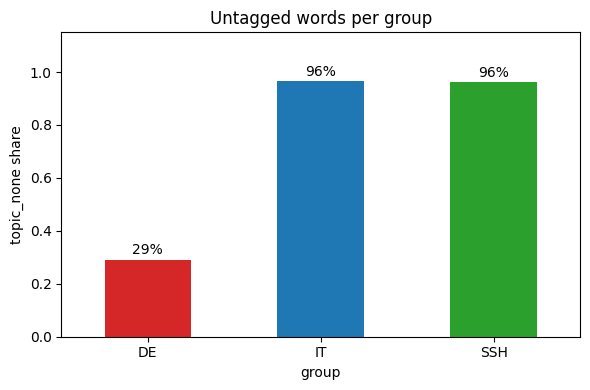

In [36]:
fig, ax = plt.subplots(figsize=(6, 4))
share["share_none"].plot(
    kind="bar", ax=ax, rot=0, color=["tab:red", "tab:blue", "tab:green"]
)
ax.set_title("Untagged words per group")
ax.set_ylabel("topic_none share")
ax.set_ylim(0, 1.15)
for i, v in enumerate(share["share_none"]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center")
plt.tight_layout()
plt.savefig("img/untagged_words_per_group.png", dpi=110, bbox_inches="tight")
plt.show()

Tagowanie `slide_id` jest skrajnie asymetryczne między grupami. Dla wywiadów z ekspertami (DE) edytorzy skrupulatnie przypisywali każdy fragment do konkretnego slajdu, a dla studentów (IT, SSH) nie przypisali prawie niczego.

W praktyce kolumny `topic_LIME`, `topic_anchor`, ..., `topic_waterfall` są dla studentów niemal zerowe, więc po standaryzacji każda z nich staje się detektorem "czy ten uczestnik należy do DE" - nie dlatego, że eksperci inaczej mówią, tylko dlatego, że ich wypowiedzi są otagowane, a wypowiedzi studentów nie.


## 8. Podsumowanie

**Co się udało:**

- Sam język wystarcza, żeby niemal bezbłędnie oddzielić ekspertów od studentów: TF-IDF (dla `k = 3`) tworzy klaster 10/12 DE i żadnym studentem, a charakterystyczne terminy tego klastra potwierdzają, że to realna różnica słownictwa.
- Kody tematyczne MAXQDA robią to jeszcze lepiej (12/12 DE) - trzeba jednak pamiętać, że to cechy nadane ręcznie przez badaczy.

**Co się nie udało:**

- Różnicy IT - SSH nie wykrywa żaden zestaw cech.
- Dobór liczby klastrów na cechach MAXQDA wskazuje, że naturalna struktura w tych danych to dwie grupy (ekspert vs. nie-ekspert), nie trzy znane z ankiety.
